# Final Analysis

In [1]:
import json
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RESULTS_DIR = Path('..') / 'results'


def load_json(path: Path):
    try:
        with path.open('r', encoding='utf-8') as handle:
            return json.load(handle)
    except FileNotFoundError:
        print(f"Missing file: {path}")
        return None


naive_json = load_json(RESULTS_DIR / 'naive_results.json')
enhanced_json = load_json(RESULTS_DIR / 'enhanced_results.json')
comparison_df = pd.read_csv(RESULTS_DIR / 'comparison_analysis.csv') if (RESULTS_DIR / 'comparison_analysis.csv').exists() else pd.DataFrame()
embedding_df = pd.read_csv(RESULTS_DIR / 'embedding_experiments.csv') if (RESULTS_DIR / 'embedding_experiments.csv').exists() else pd.DataFrame()
ragas_df = pd.read_csv(RESULTS_DIR / 'ragas_comparison.csv') if (RESULTS_DIR / 'ragas_comparison.csv').exists() else pd.DataFrame()
ragas_delta_df = pd.read_csv(RESULTS_DIR / 'ragas_comparison_delta.csv') if (RESULTS_DIR / 'ragas_comparison_delta.csv').exists() else pd.DataFrame()

# Evaluation query count: Assignment requires n=100
EVAL_QUERY_COUNT = 100  # Assignment requirement
print(f"Evaluation query count: {EVAL_QUERY_COUNT}")


def wilson_interval(p_hat: float, n: int, z: float = 1.96):
    """Wilson score interval for proportion-like metrics."""
    if n is None or n <= 0 or p_hat is None:
        return (None, None)
    p_hat = min(max(p_hat, 0.0), 1.0)
    z2 = z ** 2
    denom = 1.0 + z2 / n
    center = (p_hat + z2 / (2 * n)) / denom
    margin = (z * sqrt((p_hat * (1 - p_hat) / n) + (z2 / (4 * n ** 2)))) / denom
    return (max(center - margin, 0.0), min(center + margin, 1.0))

Evaluation query count: 100


## Prompt Strategy Comparison (Top-1)

,Prompt,TopK,F1,Exact Match
0,verification,1,51.041336,43.464052
1,baseline,1,49.270802,41.503268


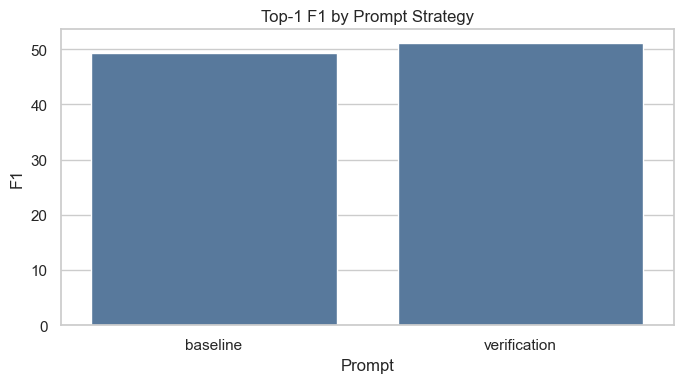

In [2]:

if not comparison_df.empty:
    for col in ['TopK', 'F1', 'Exact Match']:
        if col in comparison_df.columns:
            comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')
    top1 = comparison_df[comparison_df['TopK'] == 1].copy()
    if not top1.empty:
        top1_summary = top1[['Prompt', 'TopK', 'F1', 'Exact Match']].sort_values(['F1', 'Exact Match'], ascending=False)
        display(top1_summary.reset_index(drop=True))

        plt.figure(figsize=(7, 4))
        sns.barplot(data=top1, x='Prompt', y='F1', color='#4C78A8')
        plt.title('Top-1 F1 by Prompt Strategy')
        plt.tight_layout()
        plt.show()
    else:
        print('No Top-1 rows in comparison_analysis.csv')
else:
    print('comparison_analysis.csv missing or empty')


## Embedding Experiments

,Embedding,TopK,F1,Exact Match
0,MPNet-Base (768d),1,50.186770,42.483660
1,MiniLM-L6 (384d),1,49.270802,41.503268
2,MiniLM-L3 (256d),1,47.425122,39.869281


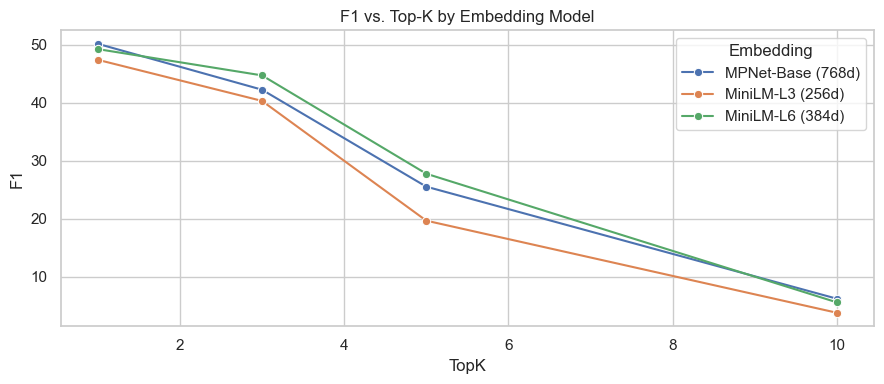

In [3]:

if not embedding_df.empty:
    rename_map = {c: c.strip() for c in embedding_df.columns}
    embedding_df.rename(columns=rename_map, inplace=True)
    for col in ['TopK', 'F1', 'Exact Match']:
        if col in embedding_df.columns:
            embedding_df[col] = pd.to_numeric(embedding_df[col], errors='coerce')

    best_rows = (
        embedding_df
        .sort_values(['F1', 'Exact Match'], ascending=False)
        .groupby('Embedding', as_index=False)
        .first()[['Embedding', 'TopK', 'F1', 'Exact Match']]
        .sort_values(['F1', 'Exact Match'], ascending=False)
    )
    display(best_rows.reset_index(drop=True))

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=embedding_df, x='TopK', y='F1', hue='Embedding', marker='o')
    plt.title('F1 vs. Top-K by Embedding Model')
    plt.tight_layout()
    plt.show()
else:
    print('embedding_experiments.csv missing or empty')


## Enhanced vs. Naive (SQuAD Metrics)

,System,EM,F1,ΔF1 vs. Naive,ΔEM vs. Naive,EM 95% CI
0,Naive (Top-1),41.503268,49.270802,0.000000,0.000000,32.34–51.30
1,Enhanced (Rewrite+Rerank),33.660131,42.409204,-6.861598,-7.843137,25.16–43.37


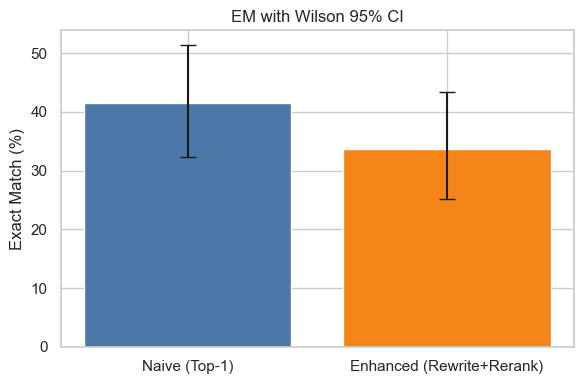

In [4]:

rows = []
for name, blob in [("Naive (Top-1)", naive_json), ("Enhanced (Rewrite+Rerank)", enhanced_json)]:
    if isinstance(blob, dict):
        metrics = blob.get('metrics', {})
        rows.append({'System': name, 'EM': metrics.get('exact_match'), 'F1': metrics.get('f1')})

if rows:
    sq = pd.DataFrame(rows)
    for col in ['EM', 'F1']:
        if sq[col].max() is not None and sq[col].max() <= 1:
            sq[col] = 100 * sq[col]
    baseline_em = sq.loc[sq['System'] == 'Naive (Top-1)', 'EM'].iloc[0]
    baseline_f1 = sq.loc[sq['System'] == 'Naive (Top-1)', 'F1'].iloc[0]
    sq['ΔF1 vs. Naive'] = sq['F1'] - baseline_f1
    sq['ΔEM vs. Naive'] = sq['EM'] - baseline_em

    if EVAL_QUERY_COUNT is not None:
        ci_values, lower_errors, upper_errors = [], [], []
        for _, row in sq.iterrows():
            low, high = wilson_interval(row['EM']/100.0, int(EVAL_QUERY_COUNT))
            if low is None:
                ci_values.append('n/a')
                lower_errors.append(0)
                upper_errors.append(0)
            else:
                ci_values.append(f"{100*low:.2f}–{100*high:.2f}")
                lower_errors.append(row['EM'] - 100*low)
                upper_errors.append(100*high - row['EM'])
        sq['EM 95% CI'] = ci_values
    else:
        sq['EM 95% CI'] = 'n/a'

    display(sq.reset_index(drop=True))

    if EVAL_QUERY_COUNT is not None:
        fig, ax = plt.subplots(figsize=(6, 4))
        means = sq['EM'].values
        errors = np.vstack([lower_errors, upper_errors])
        ax.bar(sq['System'], means, color=['#4C78A8', '#F58518'], yerr=errors, capsize=6)
        ax.set_ylabel('Exact Match (%)')
        ax.set_title('EM with Wilson 95% CI')
        plt.tight_layout()
        plt.show()
    else:
        print('Set N_OVERRIDE in the loader cell to enable EM confidence intervals.')
else:
    print('naive_results.json or enhanced_results.json missing or incomplete')


## RAGAs Comparison

,System,Samples,context_precision,context_recall,faithfulness,answer_relevancy
0,Naive (Top-1),100,0.690000,0.56,0.675833,0.640692
1,Enhanced (Rewrite+Rerank),100,0.865833,0.62,0.785000,0.671680


Metric,answer_relevancy,context_precision,context_recall,faithfulness
System,,,,
Enhanced (Rewrite+Rerank),57.48–75.59,78.54–91.92,52.21–70.90,69.47–85.42
Naive (Top-1),54.31–72.79,59.37–77.22,46.23–65.33,57.91–75.96


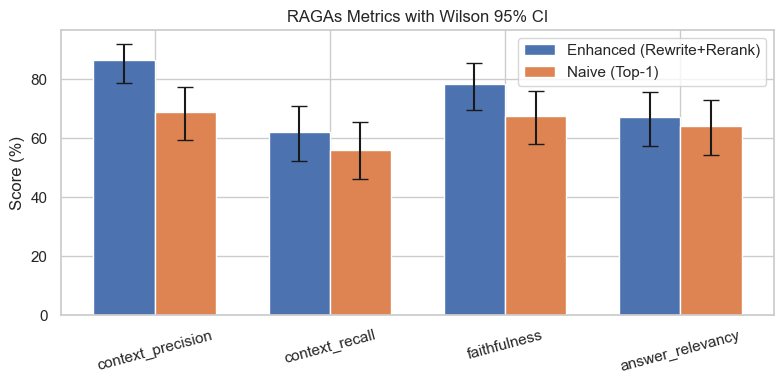

,metric,Naive (Top-1),Enhanced (Rewrite+Rerank),Delta
0,Samples,100.000000,100.000000,0.000000
1,context_precision,0.690000,0.865833,0.175833
2,context_recall,0.560000,0.620000,0.060000
3,faithfulness,0.675833,0.785000,0.109167
4,answer_relevancy,0.640692,0.671680,0.030988


In [5]:

if not ragas_df.empty:
    for col in ragas_df.columns:
        if col not in ['System', 'Samples']:
            ragas_df[col] = pd.to_numeric(ragas_df[col], errors='coerce')
    display(ragas_df)

    if 'Samples' in ragas_df.columns and ragas_df['Samples'].notna().all():
        ci_records = []
        plot_records = []
        metrics = [c for c in ragas_df.columns if c not in ['System', 'Samples']]
        for _, row in ragas_df.iterrows():
            n = int(row['Samples'])
            for metric in metrics:
                val = row[metric]
                if pd.isna(val):
                    continue
                val_prop = val / 100.0 if val > 1 else val
                low, high = wilson_interval(val_prop, n)
                if low is None:
                    ci_str = 'n/a'
                    mean = val if val <= 1 else val
                    err_low = err_high = 0
                else:
                    mean = 100 * val_prop
                    err_low = mean - 100*low
                    err_high = 100*high - mean
                    ci_str = f"{100*low:.2f}–{100*high:.2f}"
                ci_records.append({'System': row['System'], 'Metric': metric, 'CI': ci_str})
                plot_records.append({'System': row['System'], 'Metric': metric, 'Mean': mean, 'ErrLow': err_low, 'ErrHigh': err_high})
        if ci_records:
            ci_df = pd.DataFrame(ci_records)
            display(ci_df.pivot(index='System', columns='Metric', values='CI'))
        plot_df = pd.DataFrame(plot_records)
        if not plot_df.empty:
            metrics = plot_df['Metric'].unique()
            x = np.arange(len(metrics))
            width = 0.35
            fig, ax = plt.subplots(figsize=(8, 4))
            for idx, (system, data) in enumerate(plot_df.groupby('System')):
                means = [data.loc[data['Metric'] == m, 'Mean'].iloc[0] for m in metrics]
                err_l = [data.loc[data['Metric'] == m, 'ErrLow'].iloc[0] for m in metrics]
                err_u = [data.loc[data['Metric'] == m, 'ErrHigh'].iloc[0] for m in metrics]
                ax.bar(x + idx*width - width/2, means, width, label=system, yerr=np.vstack([err_l, err_u]), capsize=6)
            ax.set_xticks(x)
            ax.set_xticklabels(metrics, rotation=15)
            ax.set_ylabel('Score (%)')
            ax.set_title('RAGAs Metrics with Wilson 95% CI')
            ax.legend()
            plt.tight_layout()
            plt.show()
    else:
        print('Samples column missing; cannot compute RAGAs confidence intervals.')

    if not ragas_delta_df.empty:
        display(ragas_delta_df)
else:
    print('ragas_comparison.csv missing or empty')
